# Imports

In [2]:
using LinearAlgebra
using Random
using StatsBase
using CairoMakie  
using Revise
# CairoMakie.activate!(inline=true)
CairoMakie.activate!(type = "png", inline=true, px_per_unit=2.0, pt_per_unit=1.0)
using JLD2
using FileIO
using CSV
using GZip
using EM
using RollingFunctions
using HypothesisTests
using ShiftedArrays

# Load Data

In [3]:
filepath = ".."
include("$(filepath)/code/util.jl")
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/hmm_independentsamedist.jl")

run_hmm_independentsamedist_stay_spatial_γ2_depletion (generic function with 1 method)

Dependent Model

In [4]:
full = false  # Full cov matrix
extended = true  # standarderrors,pvalues,covmtx
rewscaled = true  # rewards = -1 / +1
results_dependent = Dict()
qvals_dependent = Dict()
loocv_dependent = Dict()

# Run
# run_hmm_leaf_stay_turn_leafspatial(data; kwargs...) = run_hmm(data; add_leaf=true, add_βleaf=true, add_stay_bias=true, add_turn_bias=true, add_leaf_spatial_bias=true, kwargs...)
# for animal in animals
#     df = load_animal(animal, ".")
#     r = run_hmm_leaf_stay_turn_leafspatial(load_animal(animal, "."); extended, rewscaled, full)
#     results_dependent[animal] = r
#     save("results/hmm_leaf_stay_turn_leafspatial_depletion_rewscaled_$(animal).jld2", "results", r)
#     Q = find_Q_vals_by_day_hmm(df, r; add_leaf=true, rewscaled, delay_turn_bias=false)
#     qvals_dependent[animal] = Q
#     CSV.write("results/Q_vals_hmm_leaf_stay_turn_leafspatial_depletion_rewscaled_$(animal).csv.gz", Q; compress=true)
# end

# Load
for animal in animals
    results_dependent[animal] = load("$(filepath)/results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")
    qvals_dependent[animal] = CSV.read("$(filepath)/results/hmm_biases/Q_vals_hmm_leaf_stay_turn_leafspatial_rewscaled_$(animal).csv.gz", DataFrame)
    # Note below is slightly simplified model until full spatial turn bias runs correctly? Took too long on cluster and was killed last time
    loocv_dependent[animal] = load("$(filepath)/results/hmm_biases_loocv/hmm_leaf_stay_turn_leafturn_rewscaled_$(animal)_loocv.jld2", "results_loocv")
end

Independent Model

In [5]:
full = false  # Full cov matrix
extended = true  # standarderrors,pvalues,covmtx
rewscaled = true  # rewards = -1 / +1
results_independent = Dict()
qvals_independent = Dict()
loocv_independent = Dict()

# Run
# run_hmm_independentsamedist_leaf_stay_turn_leafspatial(data; kwargs...) = run_hmm(data; add_leaf=true, add_βleaf=true, add_stay_bias=true, add_turn_bias=true, add_leaf_spatial_bias=true, kwargs...)
# for animal in animals
#     df = load_animal(animal, ".")
#     r = run_hmm_independentsamedist_leaf_stay_turn_leafspatial(load_animal(animal, "."); extended, rewscaled, full)
#     results_independent[animal] = r
#     save("results/hmm_independentsamedist_leaf_stay_turn_leafspatial_depletion_rewscaled_$(animal).jld2", "results", r)
#     Q = find_Q_vals_by_day_hmm(df, r; add_leaf=true, rewscaled, delay_turn_bias=false)
#     qvals_independent[animal] = Q
#     CSV.write("results/Q_vals_hmm_independentsamedist_leaf_stay_turn_leafspatial_depletion_rewscaled_$(animal).csv.gz", Q; compress=true)
# end

# Load
for animal in animals
    results_independent[animal] = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist_leaf_stay_turn_leafspatial_rewscaled_$(animal).jld2", "results")
    qvals_independent[animal] = CSV.read("$(filepath)/results/hmm_independentsamedist_biases/Q_vals_hmm_independentsamedist_leaf_stay_turn_leafspatial_rewscaled_$(animal).csv.gz", DataFrame)
    # Note below is slightly simplified model until full spatial turn bias runs correctly? Took too long on cluster and was killed last time
    loocv_independent[animal] = load("$(filepath)/results/hmm_independentsamedist_biases_loocv/hmm_independentsamedist_leaf_stay_turn_leafturn_rewscaled_$(animal)_loocv.jld2", "results_loocv")
end

# Model Comparison

## IAIC

senor
3410.3536436211634
3269.6080759833512
chimi
2134.818353703138
2094.2065478233985
j16
2561.118582028256
2460.099316383558
peanut
3628.247910589635
3500.445722288856
wilbur
2789.0516675562903
2686.133169950238


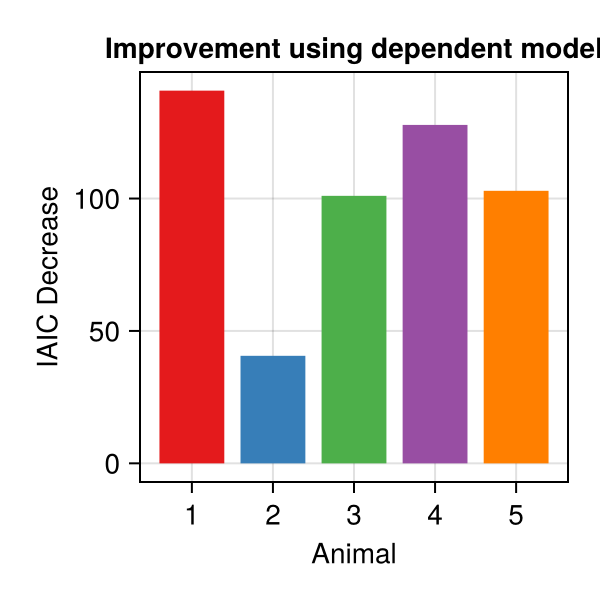

In [6]:
# Higher indicates dependent model is better
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="Improvement using dependent model", xlabel="Animal", ylabel="IAIC Decrease")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = results_independent[animal]
    r2 = results_dependent[animal]
    r1_iaic = iaic(r1.x, r1.l, r1.h, r1.betas, r1.sigma)
    r2_iaic = iaic(r2.x, r2.l, r2.h, r2.betas, r2.sigma)
    barplot!(i, r1_iaic - r2_iaic, label=animal, color=colors[i])
    println(animal)
    println(r1_iaic)
    println(r2_iaic)
end
f

## LOO-CV

senor: 107.95193109342335
chimi: 35.05910354533671
j16: 110.05824283344509
peanut: 142.54880335593316
wilbur: 94.56364219804436


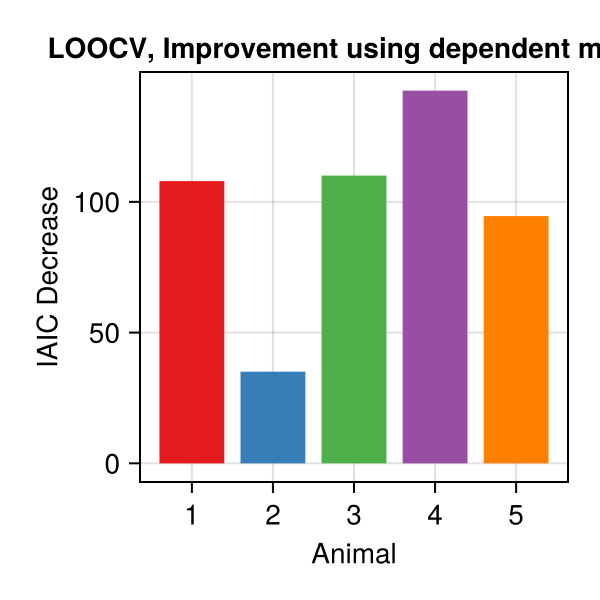

In [10]:
# Higher indicates dependent model is better
f = Figure(size=(300, 300))
ax = Axis(f[1,1], title="LOOCV, Improvement using dependent model", xlabel="Animal", ylabel="IAIC Decrease")
colors = categorical_colors(:Set1, 5)
for (i, animal) in enumerate(animals)
    r1 = loocv_independent[animal]
    r2 = loocv_dependent[animal]
    barplot!(i, sum(r1) - sum(r2), label=animal, color=colors[i])
    println("$(animal): $(sum(r1) - sum(r2))")
end
save("figures/loocv_improvement_dependent_model.pdf", f)
f

## T-tests of independent/dependent differences

For each animal, we have a per-day cross-validated likelihood, which we can use in a paired t-test

In [14]:
animal = animals[1]
r1 = loocv_independent[animal]
r2 = loocv_dependent[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          9.81381
    95% confidence interval: (4.064, 15.56)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0035

Details:
    number of observations:   11
    t-statistic:              3.8032233691465964
    degrees of freedom:       10
    empirical standard error: 2.5803932519972266


In [17]:
animal = animals[2]
r1 = loocv_independent[animal]
r2 = loocv_dependent[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          2.19119
    95% confidence interval: (0.2644, 4.118)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0285

Details:
    number of observations:   16
    t-statistic:              2.42398079905055
    degrees of freedom:       15
    empirical standard error: 0.9039650695425431


In [15]:
animal = animals[3]
r1 = loocv_independent[animal]
r2 = loocv_dependent[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          13.7573
    95% confidence interval: (8.296, 19.22)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0006

Details:
    number of observations:   8
    t-statistic:              5.956453806628427
    degrees of freedom:       7
    empirical standard error: 2.3096427506701067


In [16]:
animal = animals[4]
r1 = loocv_independent[animal]
r2 = loocv_dependent[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          17.8186
    95% confidence interval: (9.618, 26.02)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0013

Details:
    number of observations:   8
    t-statistic:              5.137920815923624
    degrees of freedom:       7
    empirical standard error: 3.4680566435098767


In [17]:
animal = animals[5]
r1 = loocv_independent[animal]
r2 = loocv_dependent[animal]
print(OneSampleTTest(r1, r2))

One sample t-test
-----------------
Population details:
    parameter of interest:   Mean
    value under h_0:         0
    point estimate:          11.8205
    95% confidence interval: (3.767, 19.87)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0104

Details:
    number of observations:   8
    t-statistic:              3.4706539860094923
    degrees of freedom:       7
    empirical standard error: 3.4058293688753842


# Model differences surrounding switches

Individual Trial Difference

Note: I think the previous plot may have included the depletion data, where there's a more pronounced difference during non-switch times

Here we're plotting the ratio of the probability of staying, aligned around switch times. So a value of 1 indicates both models equally predict staying.

What we observe is that in the lead-up to a switch (when contingencies have changed) the dependent model is much quicker to predict a switch

13219
10064
10134
10024
10322


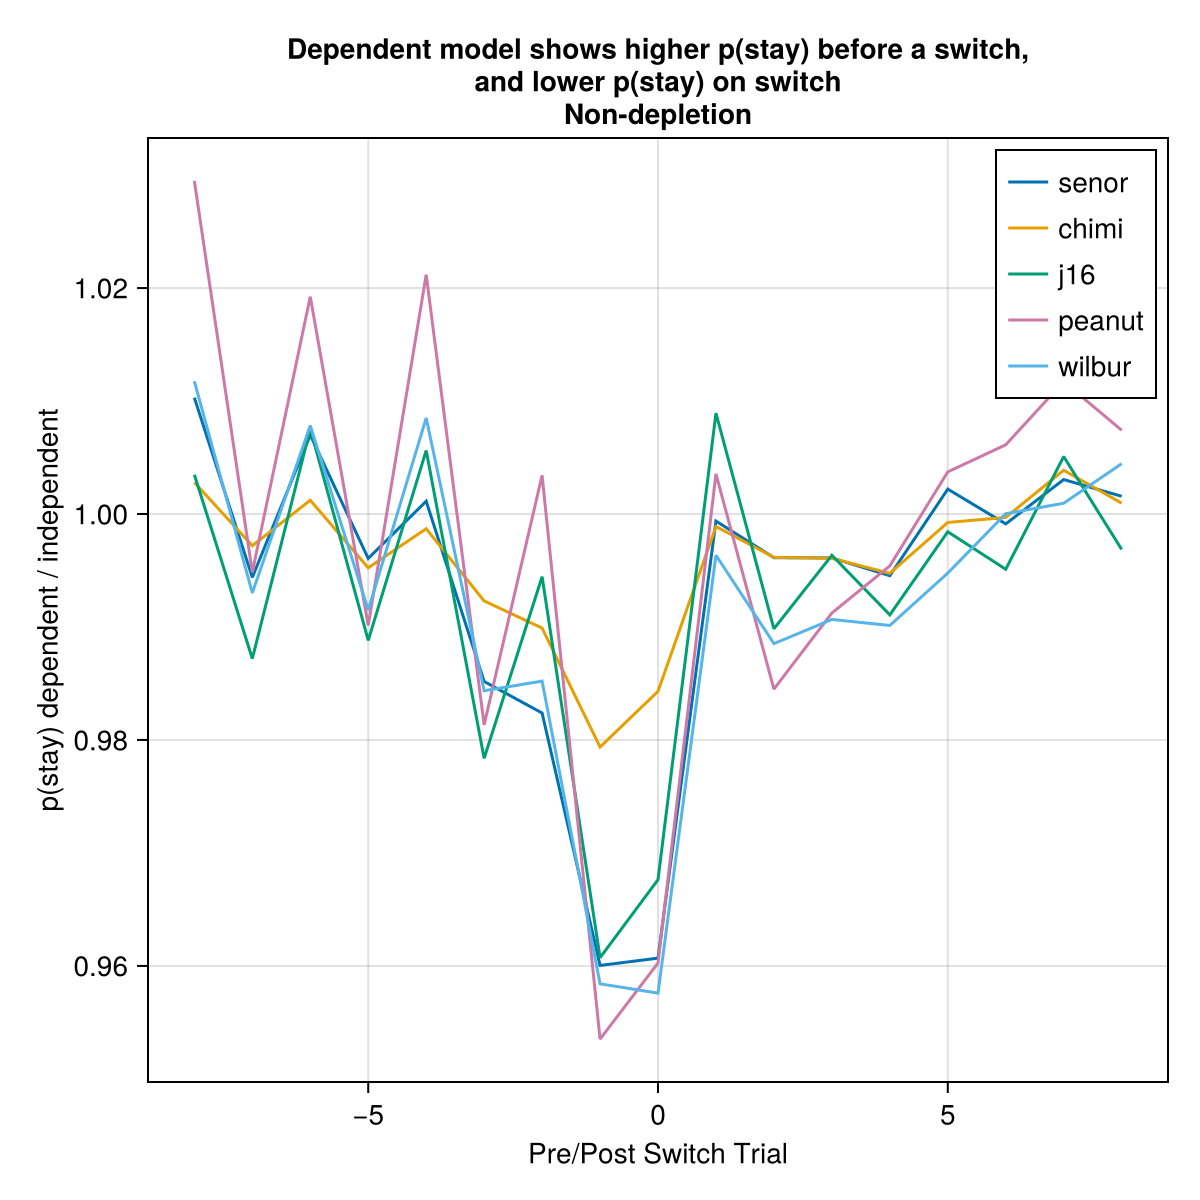

In [16]:
f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="Dependent model shows higher p(stay) before a switch,\nand lower p(stay) on switch\nNon-depletion", xlabel="Pre/Post Switch Trial", ylabel="p(stay) dependent / independent")
for animal in animals[[1,2,3,4,5]]
    df0 = qvals_dependent[animal]
    df1 = qvals_independent[animal]
    df0[!, :stayratio] .= df0[!, :stem_stay_p] ./ df1[!, :stem_stay_p]
    df = df0[.!isnan.(df0.stayratio), :]
    println(nrow(df))
    post = combine(groupby(df, :n_post_switch), :stayratio=>mean=>:stayratio)[2:10, :stayratio]
    pre = combine(groupby(df, :n_pre_switch), :stayratio=>mean=>:stayratio)[10:-1:3, :stayratio]
    lines!(-8:8, vcat(pre, post), label=animal)
end
axislegend()
f

# Largest model differences 

In [13]:
for animal in animals
    df0 = qvals_dependent[animal]
    df1 = qvals_independent[animal]

    # Calculate p(choice) and p(stay/go) for each trial for the dependent model
    # p(choice) is the probability of choosing the stem that was chosen
    # p(stay/go) is the probability of either staying or going, depending on the rat's choice
    #     e.g. the probability of the eventual stay/go decision made on that trial
    choicep0 = zeros(nrow(df0))
    staygop0 = zeros(nrow(df0))
    for i in 1:nrow(df0)
        choice = df0[i, :stemchoice]
        if choice == 1
            choicep0[i] = df0[i, :stem_1_p]
        elseif choice == 2
            choicep0[i] = df0[i, :stem_2_p]
        elseif choice == 3
            choicep0[i] = df0[i, :stem_3_p]
        end
        if df0[i, :stemswitch] == 0
            staygop0[i] = df0[i, :stem_stay_p]
        else
            staygop0[i] = 1 - df0[i, :stem_stay_p]
        end
    end

    # Calculate the same for the independent model
    choicep1 = zeros(nrow(df1))
    staygop1 = zeros(nrow(df1))
    for i in 1:nrow(df1)
        choice = df1[i, :stemchoice]
        if choice == 1
            choicep1[i] = df1[i, :stem_1_p]
        elseif choice == 2
            choicep1[i] = df1[i, :stem_2_p]
        elseif choice == 3
            choicep1[i] = df1[i, :stem_3_p]
        end
        if df1[i, :stemswitch] == 0
            staygop1[i] = df1[i, :stem_stay_p]
        else
            staygop1[i] = 1 - df1[i, :stem_stay_p]
        end
    end

    # Just need one dataframe
    df0.prevstem = ShiftedArrays.lag(df0.stemchoice)
    df1.prevstem = ShiftedArrays.lag(df1.stemchoice)
    df0[!, :choicep0] .= choicep0
    df0[!, :staygop0] .= staygop0
    df0[!, :choicep1] .= choicep1
    df0[!, :staygop1] .= staygop1
    # per-trial comparison variables
    df0[!, :choiceratio] .= choicep0 ./ choicep1
    df0[!, :choicediff] .= choicep0 .- choicep1
    df0[!, :logchoicediff] .= log.(choicep0) .- log.(choicep1)
    df0[!, :staygoratio] .= staygop0 ./ staygop1
    df0[!, :stayratio] .= df0[!, :stem_stay_p] ./ df1[!, :stem_stay_p]
    df0[!, :turnaloneratio] .= df0[!, :stem_turn_alone_p] ./ df1[!, :stem_turn_alone_p]
    df0[!, :stem_turn_alone_p_independent] .= df1[!, :stem_turn_alone_p]
    df0[!, :stem_stay_p_independent] .= df1[!, :stem_stay_p]
    # dfs_diff[animal] = df0
end

Here we're choosing the trials in order of the stay/go choice ratio.

So we start with the trial in which (assuming a go trial) we have a maximum value of $\frac{p(go|dependent)}{p(go|independent)}$

For each of the most differentiating 100 trials, plot out each model's Q-values, so we can see what difference in model estimates drove the difference in probabilities

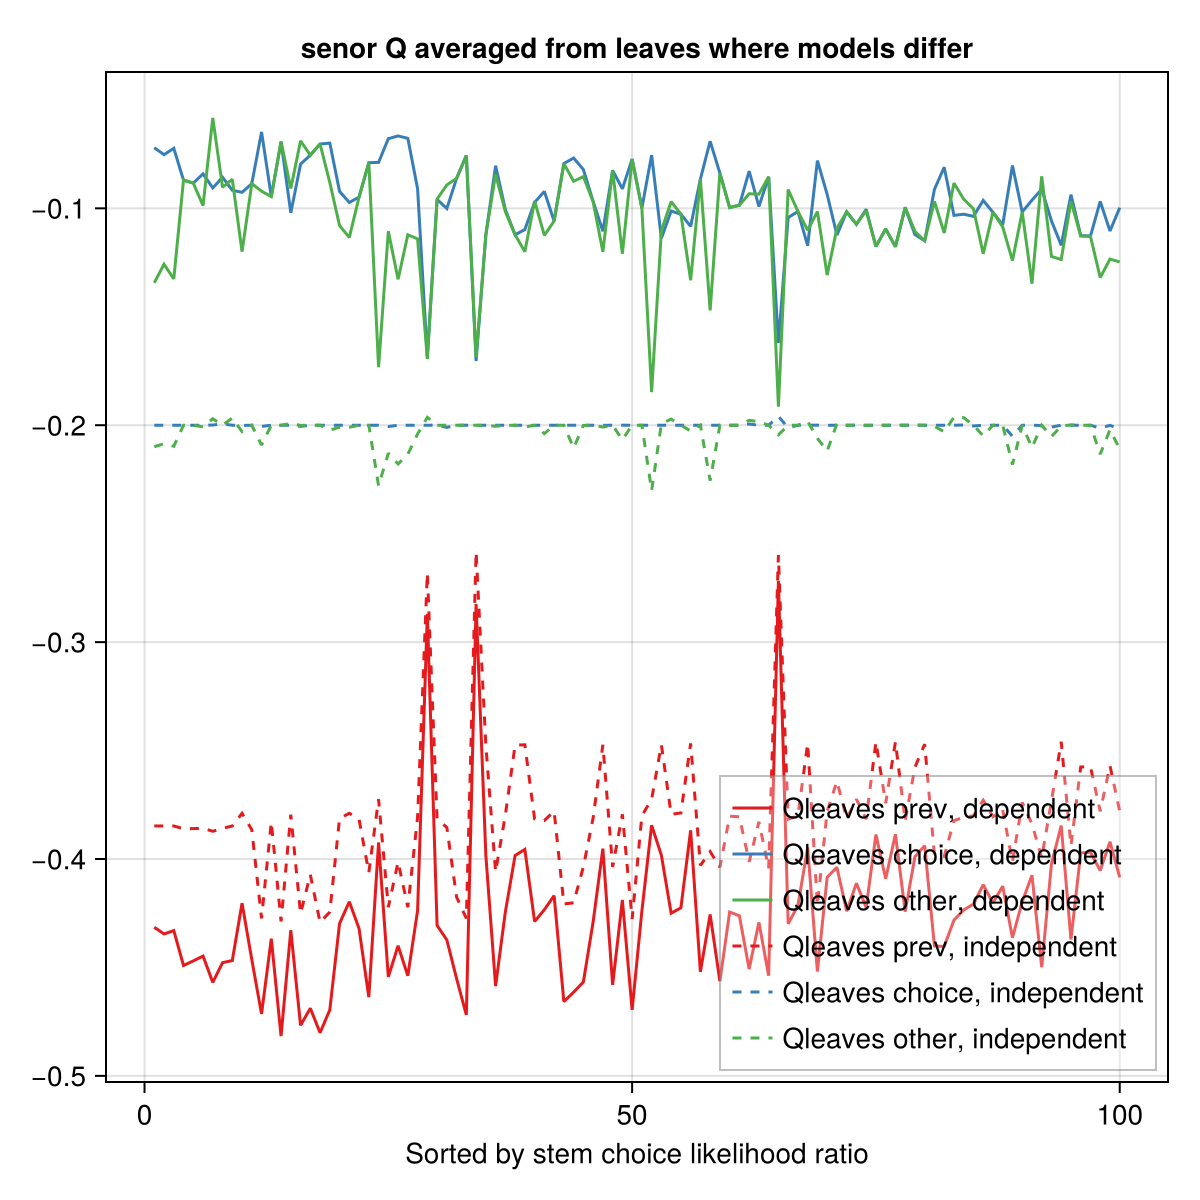

In [20]:
animal = animals[1]
inds = sortperm(qvals_dependent[animal], :choiceratio; rev=true)
nt = 100

v1s_dep = zeros(nt)
v2s_dep = zeros(nt)
v3s_dep = zeros(nt)
v1s_ind = zeros(nt)
v2s_ind = zeros(nt)
v3s_ind = zeros(nt)
x_dep = qvals_dependent[animal][inds[1:nt], :]
x_ind = qvals_independent[animal][inds[1:nt], :]
for i in 1:nt
    if x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    end
end

f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="$(animal) Q averaged from leaves where models differ", xlabel="Sorted by stem choice likelihood ratio")
colors = categorical_colors(:Set1, 5)
lines!(v1s_dep, color=colors[1], label="Qleaves prev, dependent")
lines!(v2s_dep, color=colors[2], label="Qleaves choice, dependent")
lines!(v3s_dep, color=colors[3], label="Qleaves other, dependent")
lines!(v1s_ind, linestyle=:dash, color=colors[1], label="Qleaves prev, independent")
lines!(v2s_ind, linestyle=:dash, color=colors[2], label="Qleaves choice, independent")
lines!(v3s_ind, linestyle=:dash, color=colors[3], label="Qleaves other, independent")
axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
# ax = Axis(f[2,1], title="Qstem from leaves ratio where models differ", xlabel="Sorted by stem choice likelihood ratio")
# lines!((v1s_ind ./ v1s_dep)[2:end], label="Qleaves prev (ind / dep)")
# lines!((v2s_dep ./ v2s_ind)[2:end], label="Qleaves choice (dep / ind)")
# lines!((v3s_dep ./ v3s_ind)[2:end], label="Qleaves other (dep / ind)")
# hlines!(1.0, color=:black, label=nothing)
# axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
f

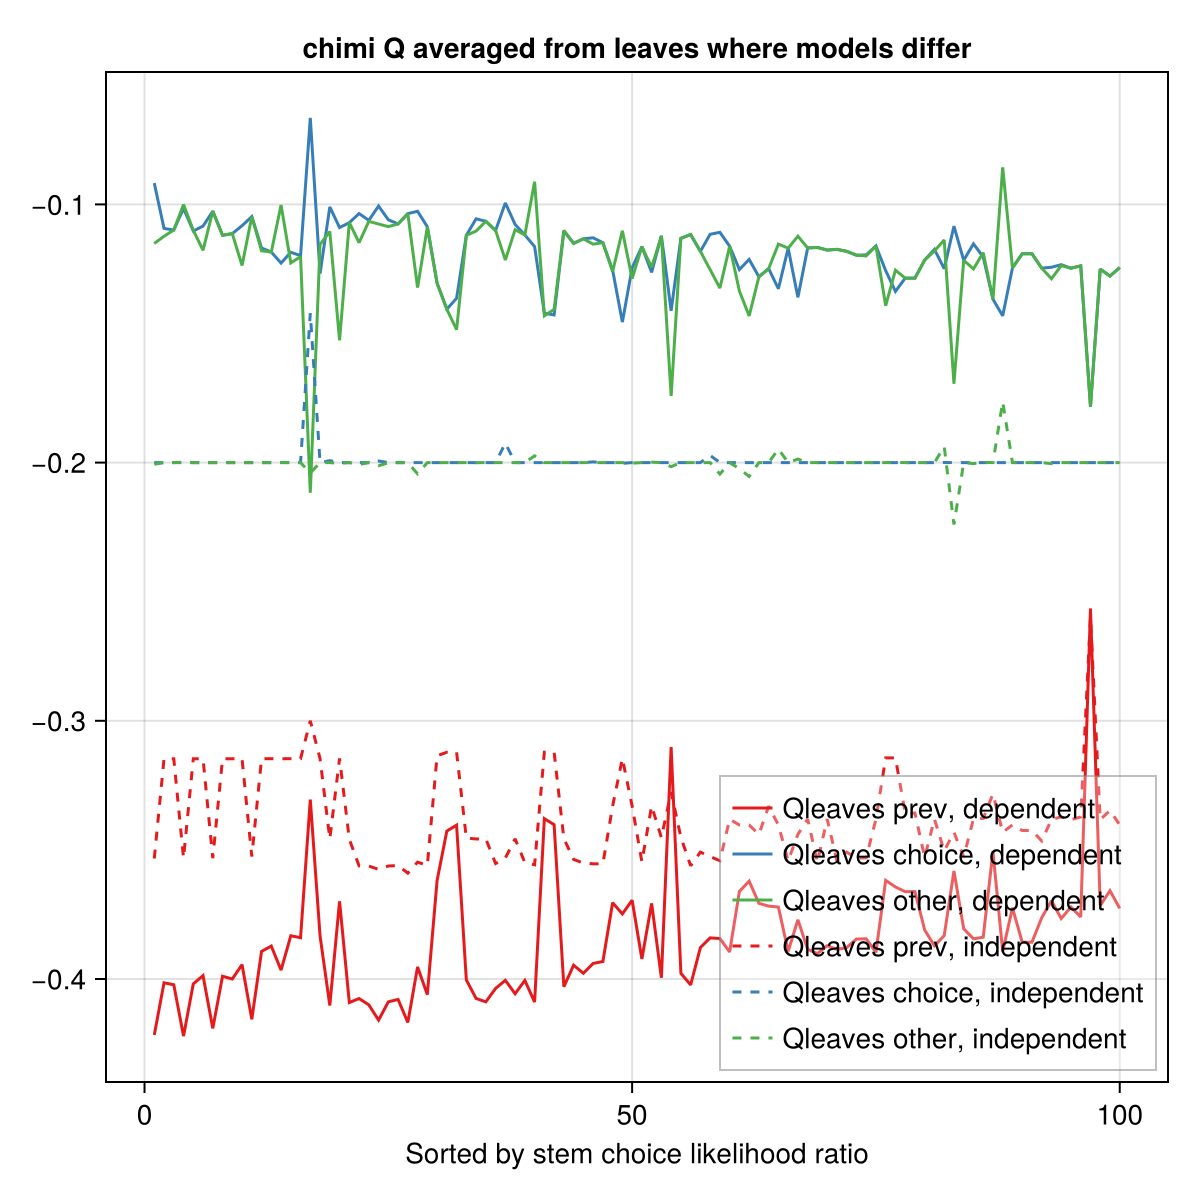

In [14]:
animal = animals[2]
inds = sortperm(qvals_dependent[animal], :choiceratio; rev=true)
nt = 100

v1s_dep = zeros(nt)
v2s_dep = zeros(nt)
v3s_dep = zeros(nt)
v1s_ind = zeros(nt)
v2s_ind = zeros(nt)
v3s_ind = zeros(nt)
x_dep = qvals_dependent[animal][inds[1:nt], :]
x_ind = qvals_independent[animal][inds[1:nt], :]
for i in 1:nt
    if x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    end
end

f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="$(animal) Q averaged from leaves where models differ", xlabel="Sorted by stem choice likelihood ratio")
colors = categorical_colors(:Set1, 5)
lines!(v1s_dep, color=colors[1], label="Qleaves prev, dependent")
lines!(v2s_dep, color=colors[2], label="Qleaves choice, dependent")
lines!(v3s_dep, color=colors[3], label="Qleaves other, dependent")
lines!(v1s_ind, linestyle=:dash, color=colors[1], label="Qleaves prev, independent")
lines!(v2s_ind, linestyle=:dash, color=colors[2], label="Qleaves choice, independent")
lines!(v3s_ind, linestyle=:dash, color=colors[3], label="Qleaves other, independent")
axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
# ax = Axis(f[2,1], title="Qstem from leaves ratio where models differ", xlabel="Sorted by stem choice likelihood ratio")
# lines!((v1s_ind ./ v1s_dep)[2:end], label="Qleaves prev (ind / dep)")
# lines!((v2s_dep ./ v2s_ind)[2:end], label="Qleaves choice (dep / ind)")
# lines!((v3s_dep ./ v3s_ind)[2:end], label="Qleaves other (dep / ind)")
# hlines!(1.0, color=:black, label=nothing)
# axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
f

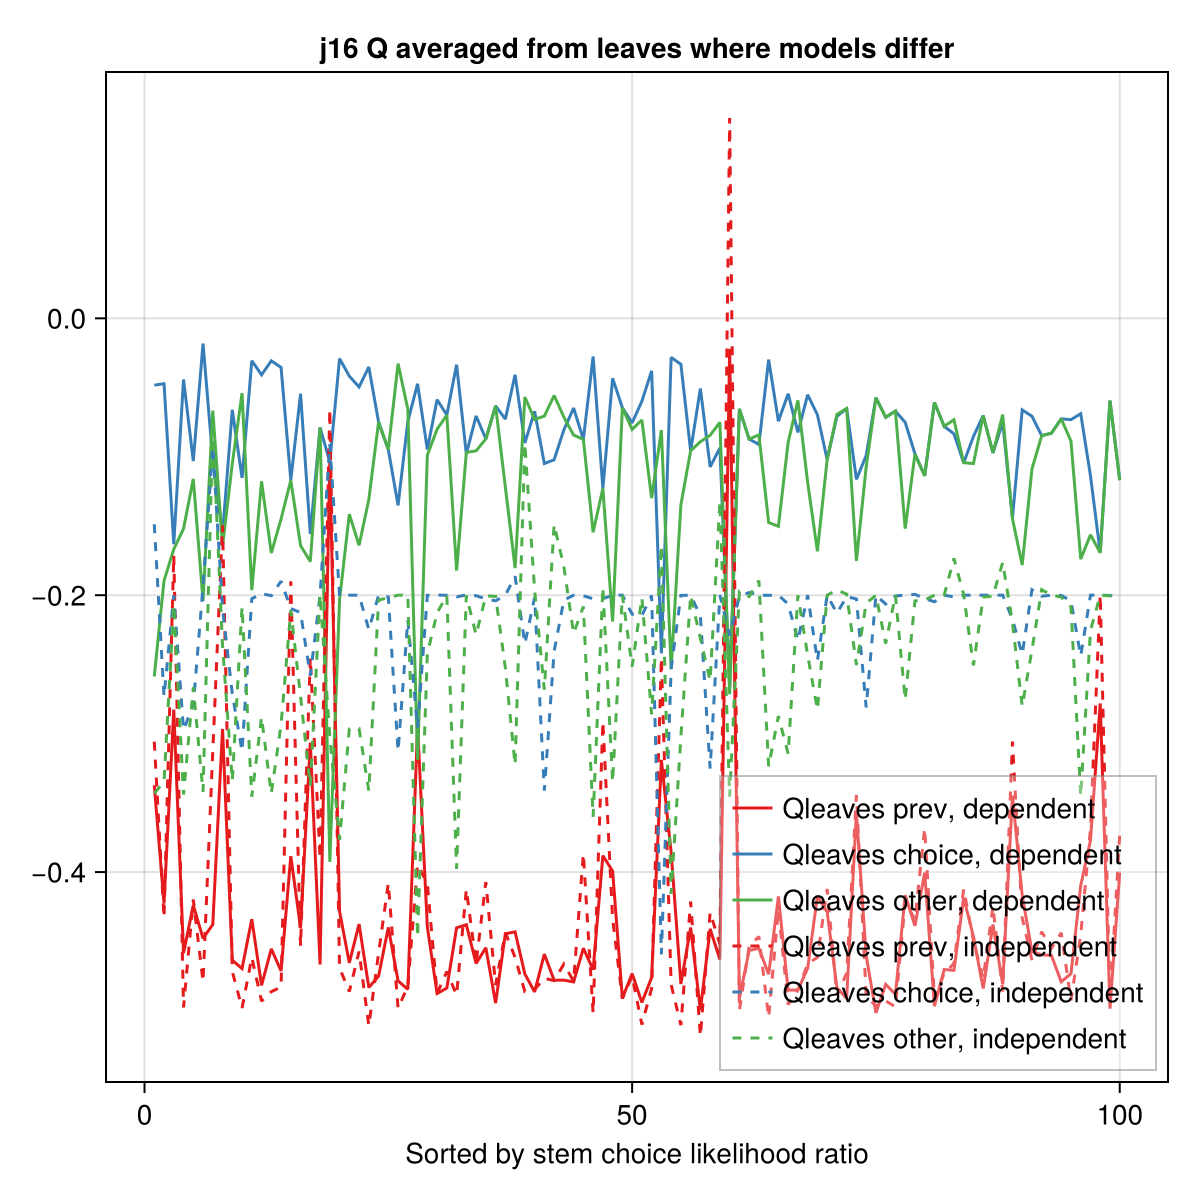

In [21]:
animal = animals[3]
inds = sortperm(qvals_dependent[animal], :choiceratio; rev=true)
nt = 100

v1s_dep = zeros(nt)
v2s_dep = zeros(nt)
v3s_dep = zeros(nt)
v1s_ind = zeros(nt)
v2s_ind = zeros(nt)
v3s_ind = zeros(nt)
x_dep = qvals_dependent[animal][inds[1:nt], :]
x_ind = qvals_independent[animal][inds[1:nt], :]
for i in 1:nt
    if x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    end
end

f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="$(animal) Q averaged from leaves where models differ", xlabel="Sorted by stem choice likelihood ratio")
colors = categorical_colors(:Set1, 5)
lines!(v1s_dep, color=colors[1], label="Qleaves prev, dependent")
lines!(v2s_dep, color=colors[2], label="Qleaves choice, dependent")
lines!(v3s_dep, color=colors[3], label="Qleaves other, dependent")
lines!(v1s_ind, linestyle=:dash, color=colors[1], label="Qleaves prev, independent")
lines!(v2s_ind, linestyle=:dash, color=colors[2], label="Qleaves choice, independent")
lines!(v3s_ind, linestyle=:dash, color=colors[3], label="Qleaves other, independent")
axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
# ax = Axis(f[2,1], title="Qstem from leaves ratio where models differ", xlabel="Sorted by stem choice likelihood ratio")
# lines!((v1s_ind ./ v1s_dep)[2:end], label="Qleaves prev (ind / dep)")
# lines!((v2s_dep ./ v2s_ind)[2:end], label="Qleaves choice (dep / ind)")
# lines!((v3s_dep ./ v3s_ind)[2:end], label="Qleaves other (dep / ind)")
# hlines!(1.0, color=:black, label=nothing)
# axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
f

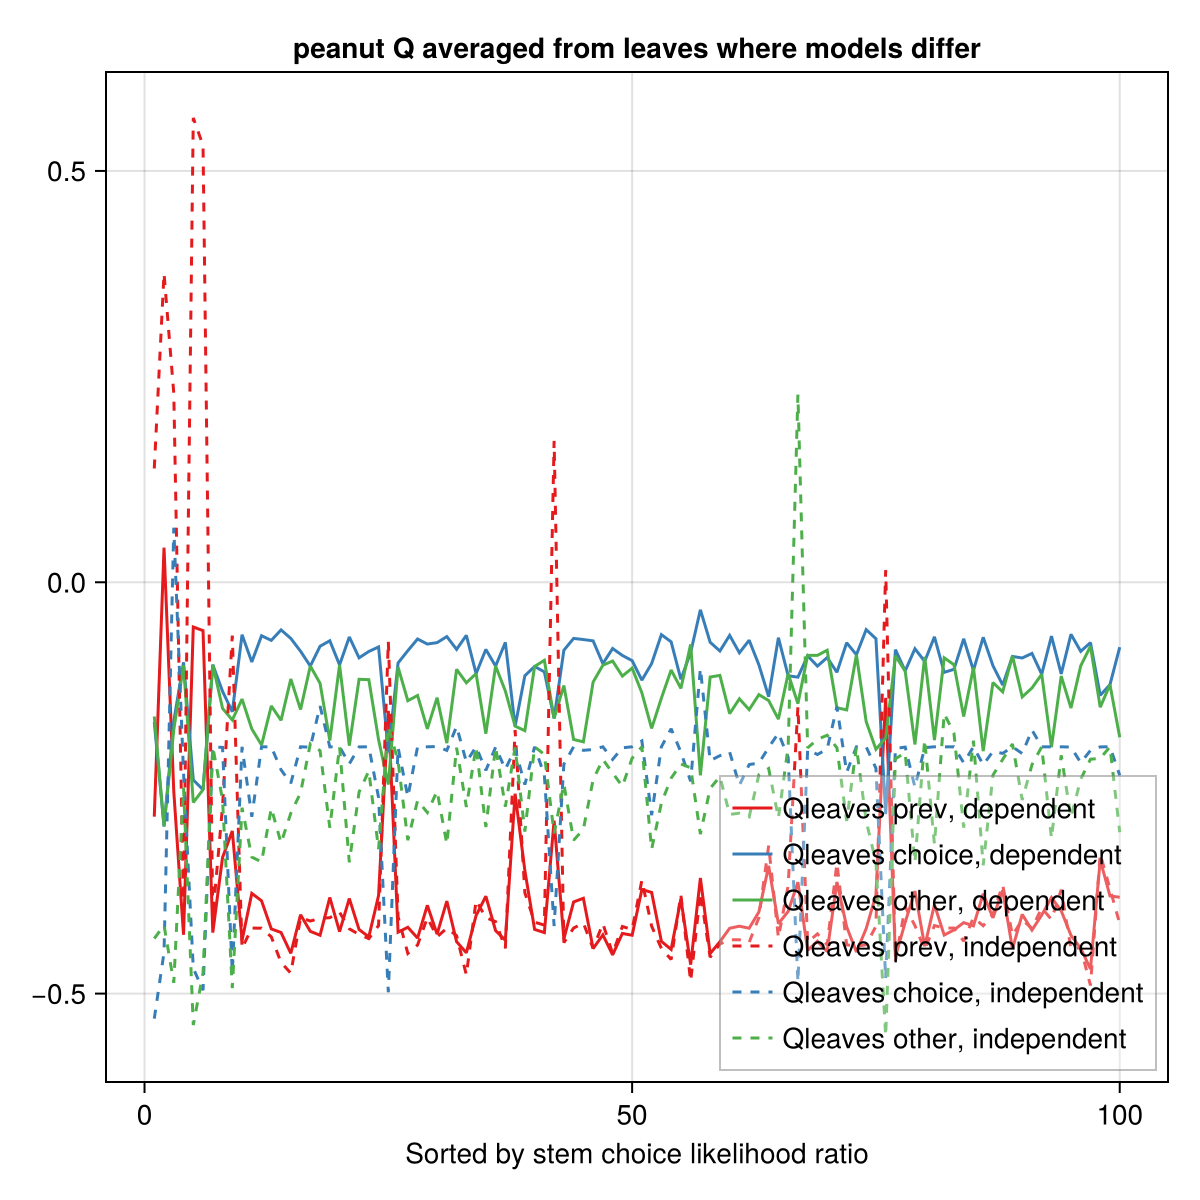

In [22]:
animal = animals[4]
inds = sortperm(qvals_dependent[animal], :choiceratio; rev=true)
nt = 100

v1s_dep = zeros(nt)
v2s_dep = zeros(nt)
v3s_dep = zeros(nt)
v1s_ind = zeros(nt)
v2s_ind = zeros(nt)
v3s_ind = zeros(nt)
x_dep = qvals_dependent[animal][inds[1:nt], :]
x_ind = qvals_independent[animal][inds[1:nt], :]
for i in 1:nt
    if x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    end
end

f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="$(animal) Q averaged from leaves where models differ", xlabel="Sorted by stem choice likelihood ratio")
colors = categorical_colors(:Set1, 5)
lines!(v1s_dep, color=colors[1], label="Qleaves prev, dependent")
lines!(v2s_dep, color=colors[2], label="Qleaves choice, dependent")
lines!(v3s_dep, color=colors[3], label="Qleaves other, dependent")
lines!(v1s_ind, linestyle=:dash, color=colors[1], label="Qleaves prev, independent")
lines!(v2s_ind, linestyle=:dash, color=colors[2], label="Qleaves choice, independent")
lines!(v3s_ind, linestyle=:dash, color=colors[3], label="Qleaves other, independent")
axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
# ax = Axis(f[2,1], title="Qstem from leaves ratio where models differ", xlabel="Sorted by stem choice likelihood ratio")
# lines!((v1s_ind ./ v1s_dep)[2:end], label="Qleaves prev (ind / dep)")
# lines!((v2s_dep ./ v2s_ind)[2:end], label="Qleaves choice (dep / ind)")
# lines!((v3s_dep ./ v3s_ind)[2:end], label="Qleaves other (dep / ind)")
# hlines!(1.0, color=:black, label=nothing)
# axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
f

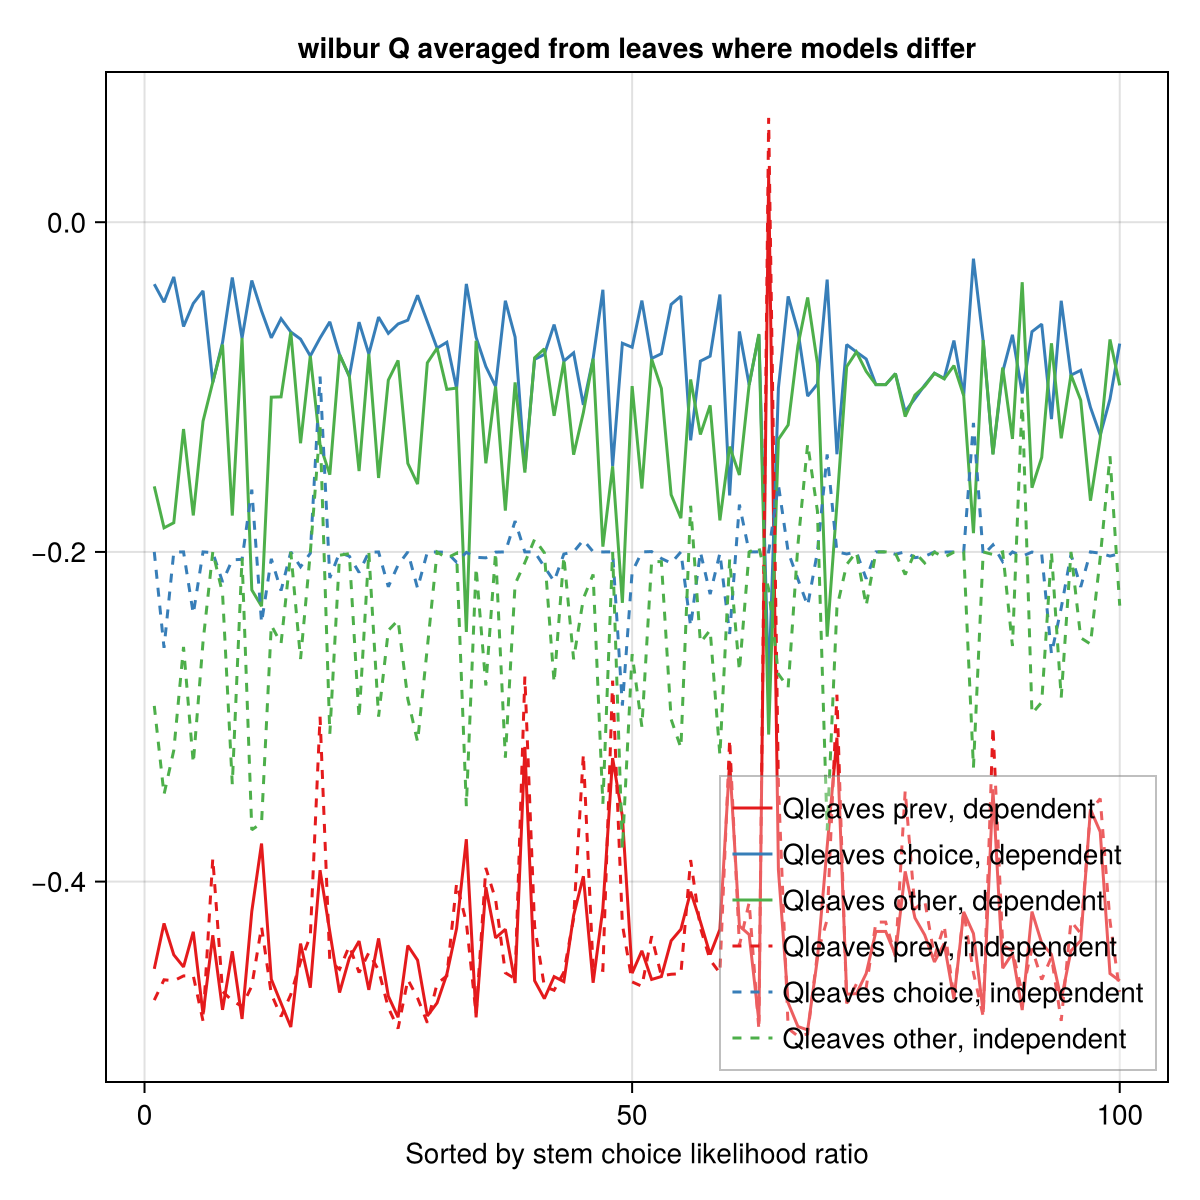

In [23]:
animal = animals[5]
inds = sortperm(qvals_dependent[animal], :choiceratio; rev=true)
nt = 100

v1s_dep = zeros(nt)
v2s_dep = zeros(nt)
v3s_dep = zeros(nt)
v1s_ind = zeros(nt)
v2s_ind = zeros(nt)
v3s_ind = zeros(nt)
x_dep = qvals_dependent[animal][inds[1:nt], :]
x_ind = qvals_independent[animal][inds[1:nt], :]
for i in 1:nt
    if x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 1 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
    elseif x_ind.prevstem[i] == 2 && x_ind.stemchoice[i] == 3
        v1s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v2s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v2s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 1
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v3s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
        v3s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
    elseif x_ind.prevstem[i] == 3 && x_ind.stemchoice[i] == 2
        v1s_ind[i] = (x_ind.Q5[i] + x_ind.Q6[i]) ./ 2
        v2s_ind[i] = (x_ind.Q3[i] + x_ind.Q4[i]) ./ 2
        v3s_ind[i] = (x_ind.Q1[i] + x_ind.Q2[i]) ./ 2
        v1s_dep[i] = (x_dep.Q5[i] + x_dep.Q6[i]) ./ 2
        v2s_dep[i] = (x_dep.Q3[i] + x_dep.Q4[i]) ./ 2
        v3s_dep[i] = (x_dep.Q1[i] + x_dep.Q2[i]) ./ 2
    end
end

f = Figure(size=(600, 600))
ax = Axis(f[1,1], title="$(animal) Q averaged from leaves where models differ", xlabel="Sorted by stem choice likelihood ratio")
colors = categorical_colors(:Set1, 5)
lines!(v1s_dep, color=colors[1], label="Qleaves prev, dependent")
lines!(v2s_dep, color=colors[2], label="Qleaves choice, dependent")
lines!(v3s_dep, color=colors[3], label="Qleaves other, dependent")
lines!(v1s_ind, linestyle=:dash, color=colors[1], label="Qleaves prev, independent")
lines!(v2s_ind, linestyle=:dash, color=colors[2], label="Qleaves choice, independent")
lines!(v3s_ind, linestyle=:dash, color=colors[3], label="Qleaves other, independent")
axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
# ax = Axis(f[2,1], title="Qstem from leaves ratio where models differ", xlabel="Sorted by stem choice likelihood ratio")
# lines!((v1s_ind ./ v1s_dep)[2:end], label="Qleaves prev (ind / dep)")
# lines!((v2s_dep ./ v2s_ind)[2:end], label="Qleaves choice (dep / ind)")
# lines!((v3s_dep ./ v3s_ind)[2:end], label="Qleaves other (dep / ind)")
# hlines!(1.0, color=:black, label=nothing)
# axislegend(; position = :rb, framecolor = (:grey, 0.5), backgroundcolor = (:white, 0.3))
f

Rather than sorting, we can just look across trials at how the choice likelihood ratio varies.

Dotted lines are stem switches, we're plotting the log likelihood ratio, so 0 is equivalent models

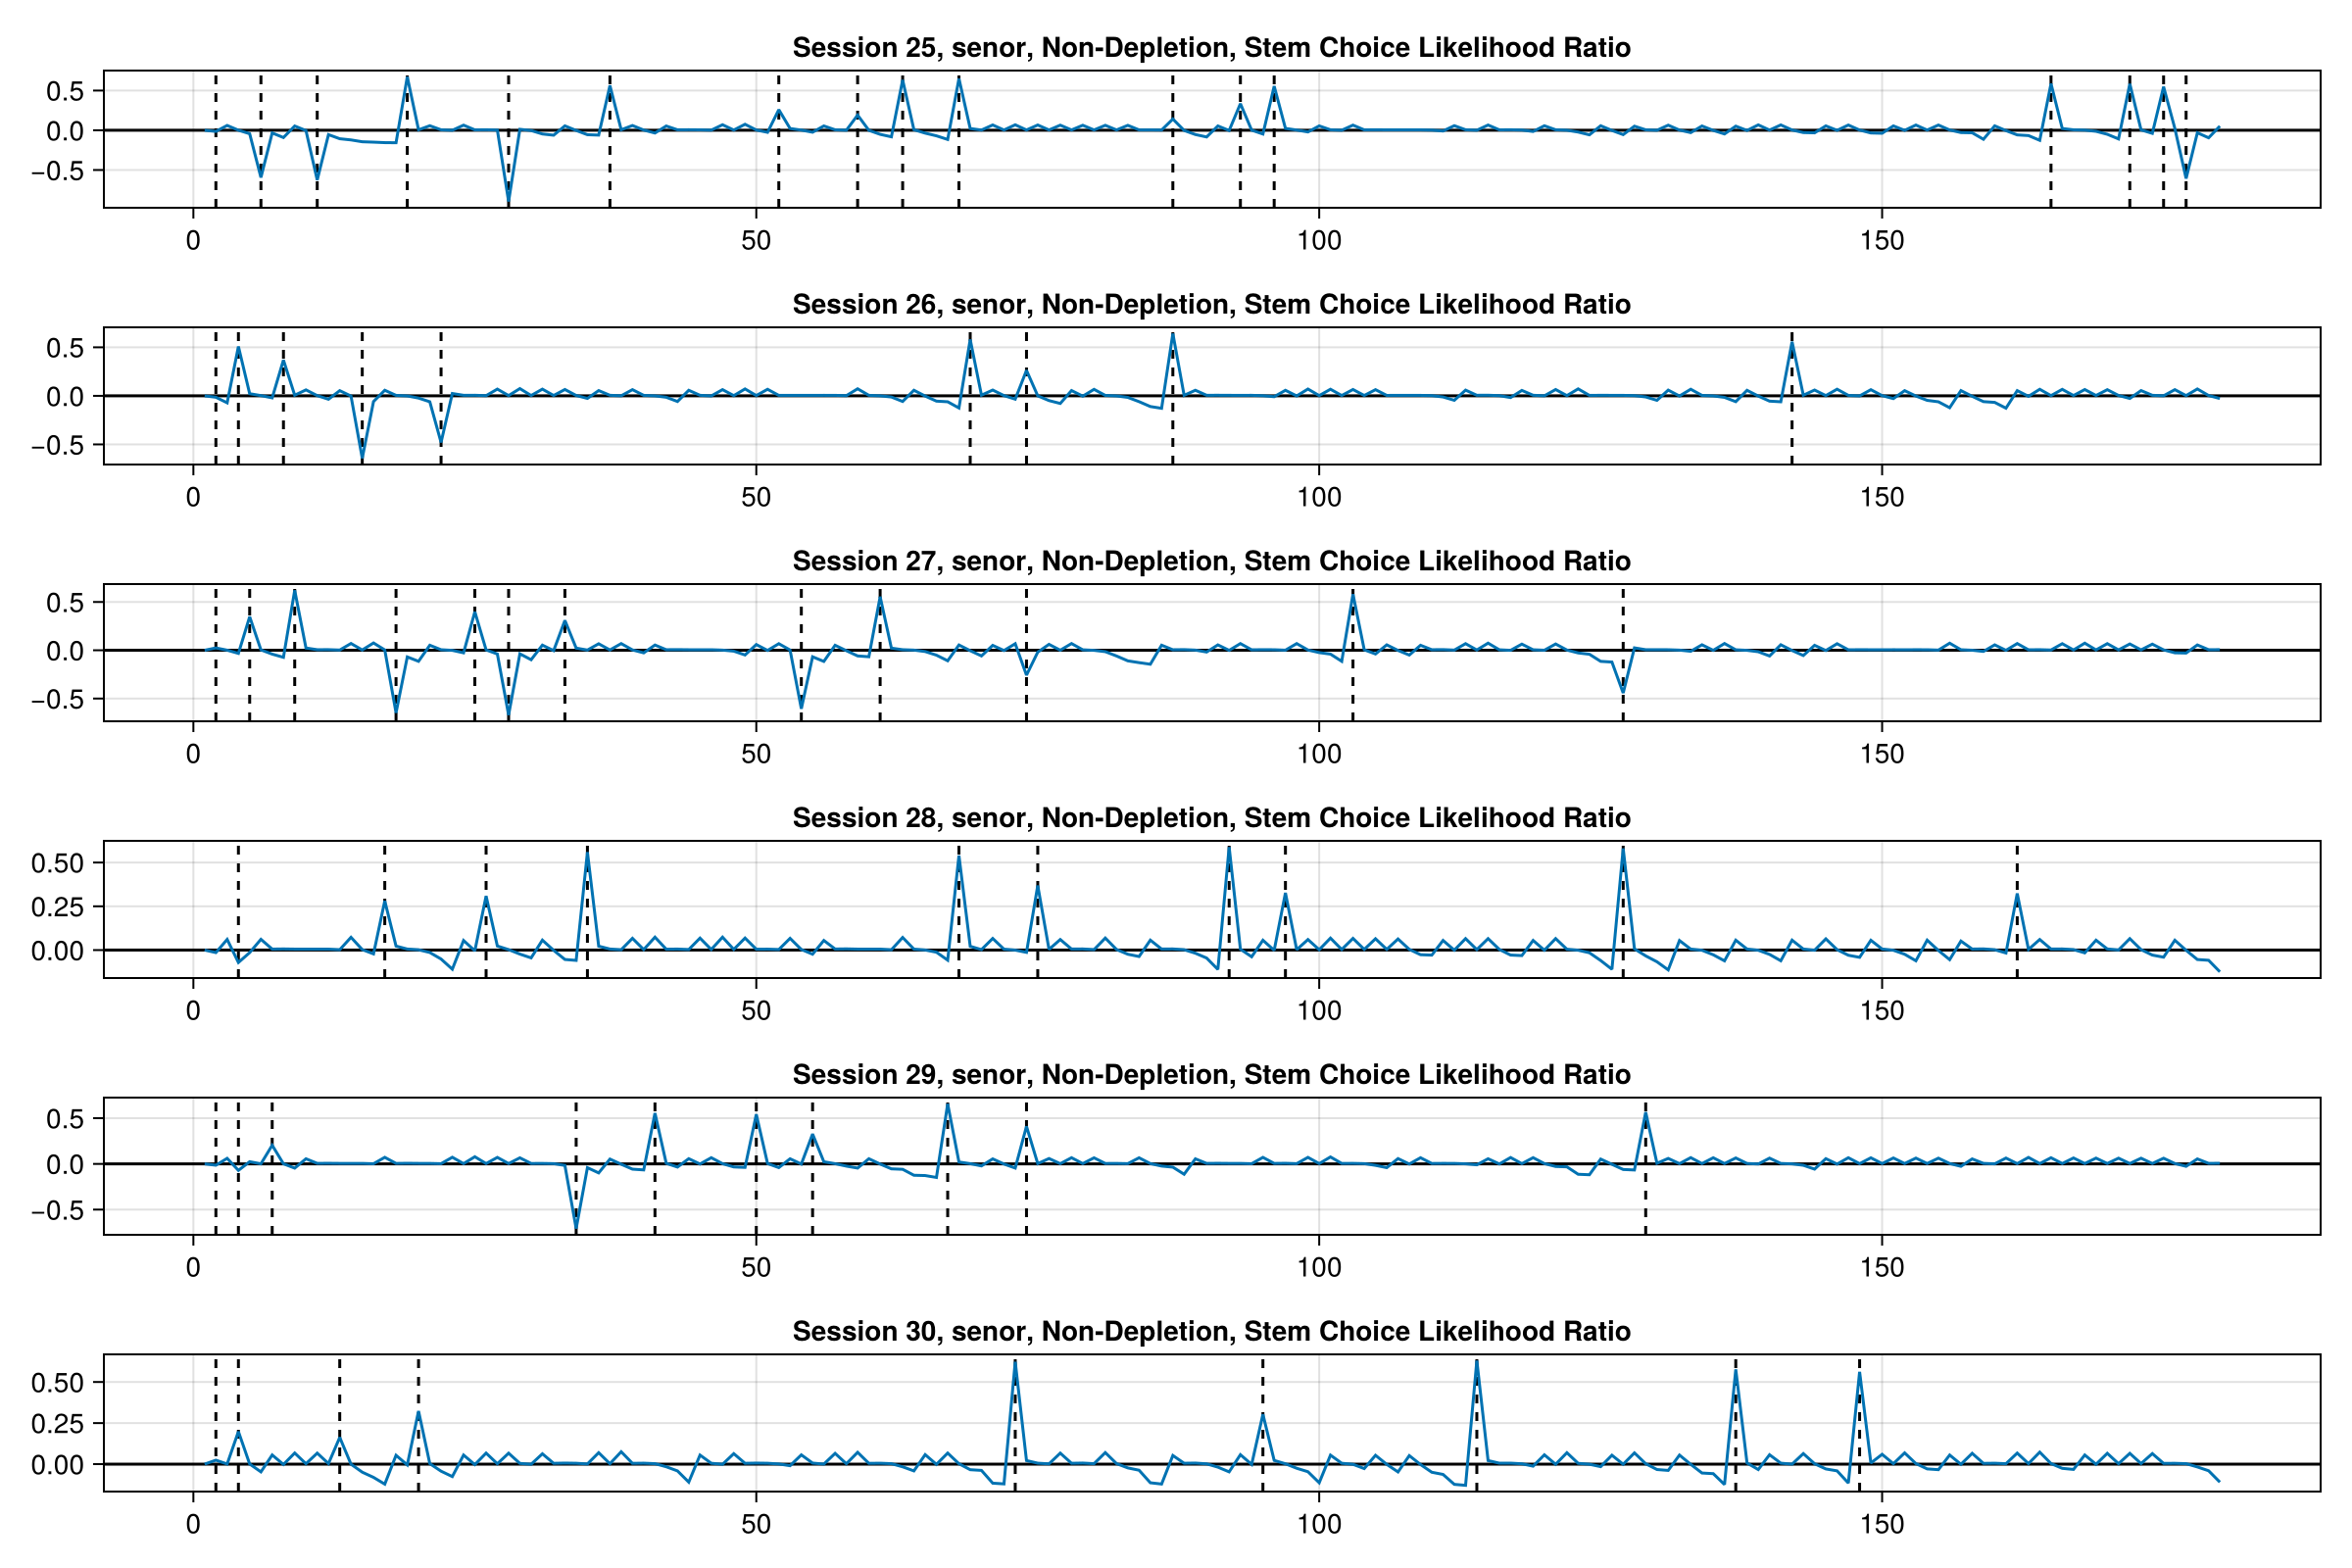

In [24]:
f = Figure(size=(1200, 800))
animal = animals[1]

for (i, session) in enumerate(25:30)
    ax = Axis(f[i,1], title="Session $(session), $(animal), Non-Depletion, Stem Choice Likelihood Ratio")
    hlines!([0.0], color=:black)
    df = qvals_dependent[animal]
    vlines!(findall(df[df.daysessionnum .== session, :stemswitch]), linestyle=:dash, color=:black)
    lines!(df[df.daysessionnum .== session, :logchoicediff])
end
f

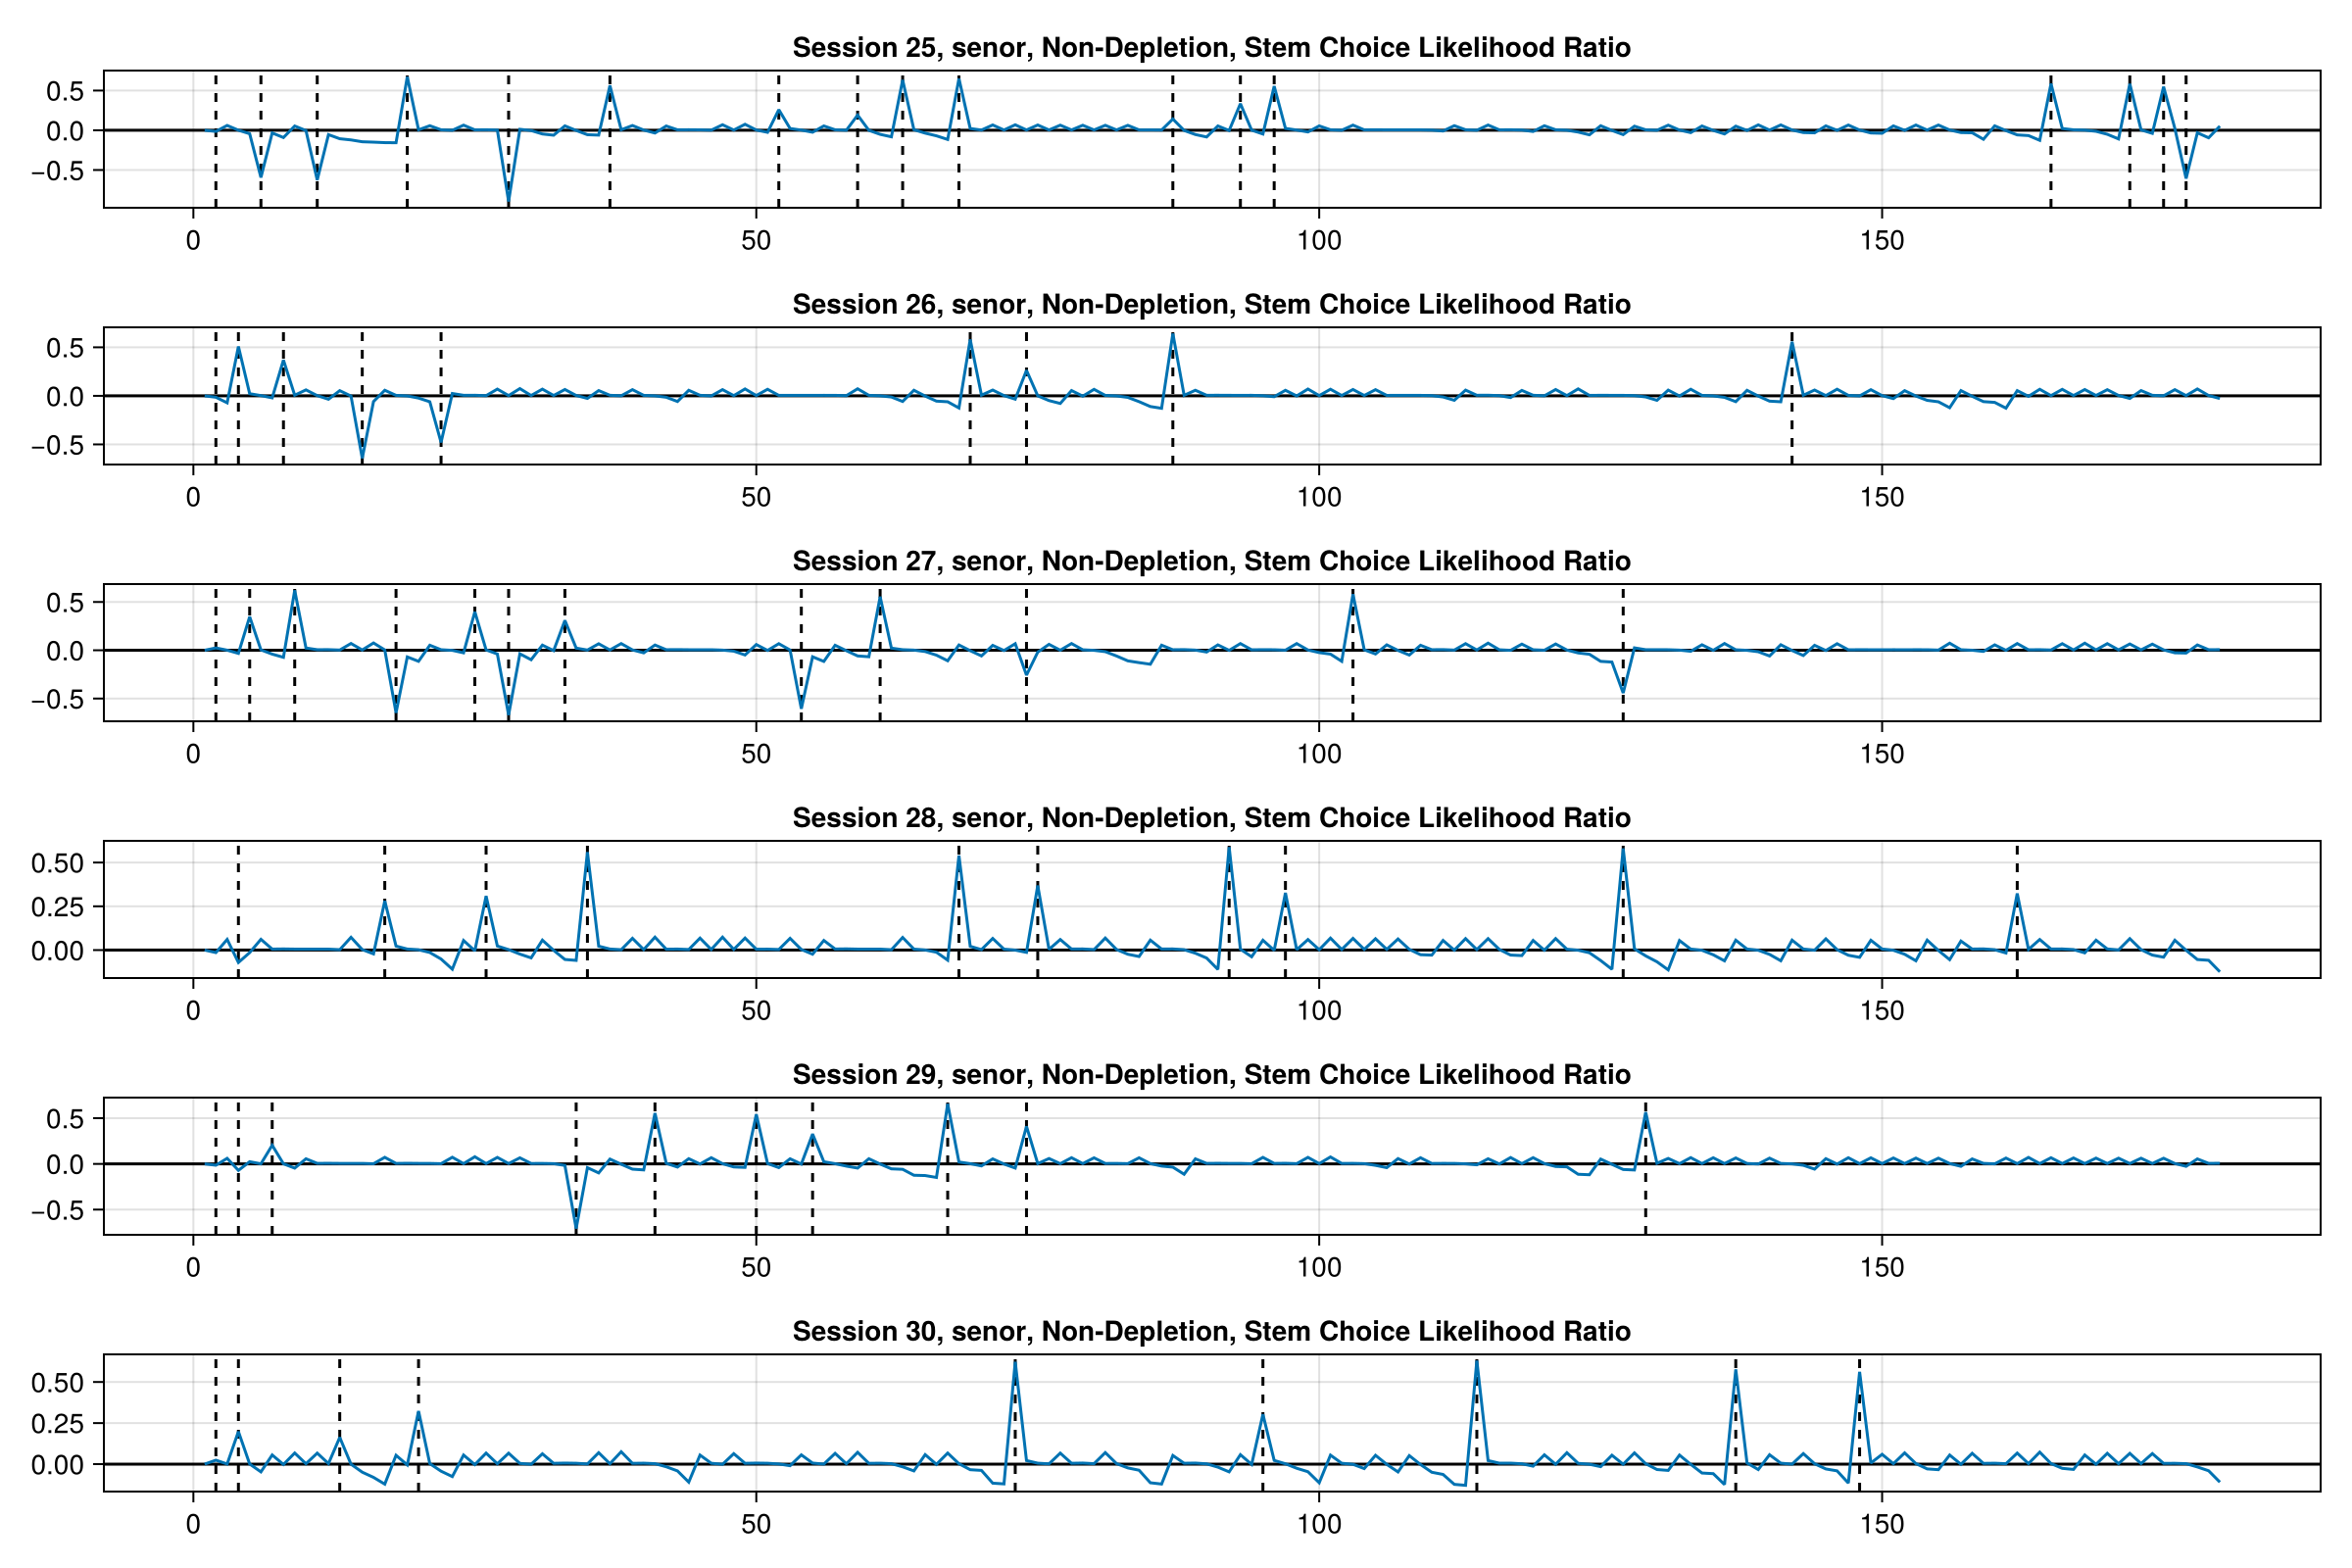

In [25]:
f = Figure(size=(1200, 800))
animal = animals[1]

for (i, session) in enumerate(25:30)
    ax = Axis(f[i,1], title="Session $(session), $(animal), Non-Depletion, Stem Choice Likelihood Ratio")
    hlines!([0.0], color=:black)
    df = qvals_dependent[animal]
    inds = df[df.daysessionnum .== session, :stemswitch]
    
    vlines!(findall(df[df.daysessionnum .== session, :stemswitch]), linestyle=:dash, color=:black)
    lines!(df[df.daysessionnum .== session, :logchoicediff])
end
f

# Stem Switch Choices

Finally, on stem switches, does it seem like we consistently are able to predict what stem we switch to better w/ the dependent model?

Plotting out per-session sum of log probabilites, normalized s.t. zero means we're at-chance with prediction.

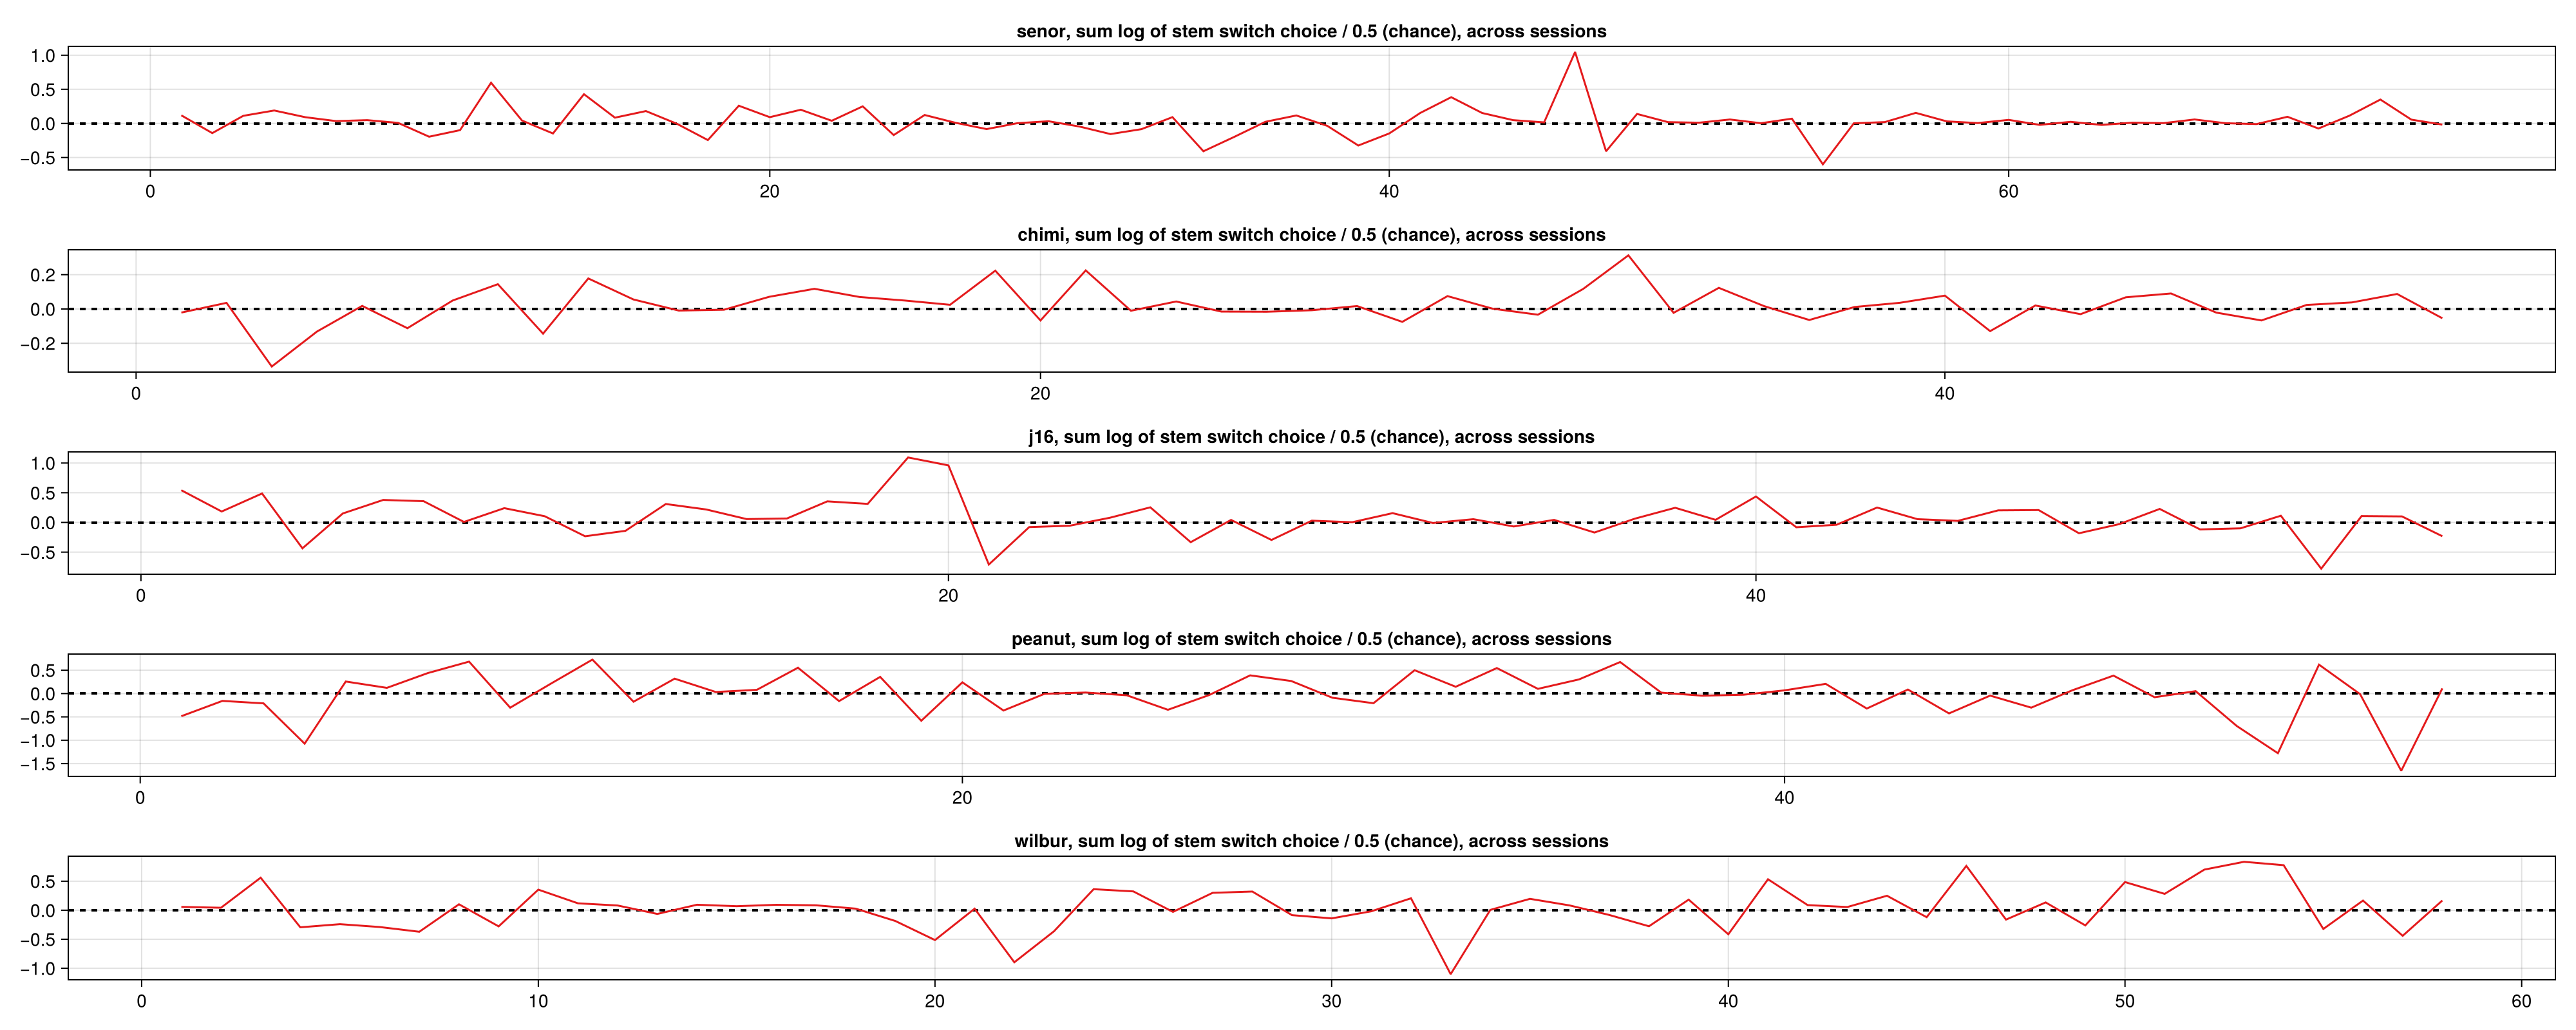

In [15]:
f = Figure(size=(2000, 800))
for (i, animal) in enumerate(animals[[1,2,3,4,5]])
    ax = Axis(f[i,1], title="$(animal), sum log of stem switch choice / 0.5 (chance), across sessions")
    colors = categorical_colors(:Set1, 5)

    nondep_sessions = unique(qvals_dependent[animal][:, :daysessionnum])

    avg_turn = zeros(Float64, length(nondep_sessions))
    for (j, session) in enumerate(nondep_sessions)
        df_ses = qvals_dependent[animal][qvals_dependent[animal].daysessionnum .== session, :]
        df_ses2 = qvals_independent[animal][qvals_independent[animal].daysessionnum .== session, :]
        avg_turn[j] = sum(log.(df_ses[df_ses[:, :stemswitch], :stem_turn_alone_p][2:end] ./ df_ses2[df_ses2[:, :stemswitch], :stem_turn_alone_p][2:end]))
        hlines!([0.0], color=:black, linestyle=:dash)
        # ylims!(0.0, 1.0)
    end
    lines!(nondep_sessions, avg_turn, label="No Leaf", color=colors[1])
end
f